# line get

In [1]:
!pip install -q huggingface_hub transformers torch shap datasets pandas


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip


In [2]:
!pip install "datasets<2.14"


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip


In [3]:
# from datasets import load_dataset
import pandas as pd
import numpy as np

In [4]:
print(pd.__version__)

2.3.3


In [5]:
url = "https://huggingface.co/datasets/AKS-DHLAB/KPoEM/resolve/main/KPoEM_line_dataset_v4.tsv"

df = pd.read_csv(
    url,
    sep="\t",
    encoding="utf-8",
    quoting=3
)

df.head()


,line_id,poem_id,text,sub_title,title,poet,annotator_01,annotator_02,annotator_03,annotator_04,annotator_05
0,1,1,죽는 날까지 하늘을 우러러,NaN,서시,윤동주,비장함,비장함,"뿌듯함, 비장함","비장함, 뿌듯함, 감동/감탄","비장함, 서러움, 슬픔"
1,2,1,"한 점 부끄럼이 없기를,",NaN,서시,윤동주,"부끄러움, 비장함","부끄러움, 비장함, 기대감, 불안/걱정, 서러움, 슬픔","깨달음, 비장함, 뿌듯함","비장함, 부끄러움, 기대감",비장함
2,3,1,잎새에 이는 바람에도,NaN,서시,윤동주,"기대감, 신기함/관심","기대감, 불안/걱정, 비장함","슬픔, 서러움, 불안/걱정, 당황/난처","비장함, 슬픔","감동/감탄, 신기함/관심, 편안/쾌적, 기대감"
3,4,1,나는 괴로워했다.,NaN,서시,윤동주,"절망, 슬픔, 패배/자기혐오","절망, 슬픔, 패배/자기혐오, 죄책감, 힘듦/지침, 비장함","당황/난처, 서러움, 죄책감, 패배/자기혐오","비장함, 슬픔, 패배/자기혐오, 절망, 힘듦/지침","슬픔, 서러움, 절망, 힘듦/지침, 패배/자기혐오"
4,5,1,별을 노래하는 마음으로,NaN,서시,윤동주,"기쁨, 신기함/관심, 즐거움/신남, 흐뭇함(귀여움/예쁨), 뿌듯함","기쁨, 뿌듯함, 감동/감탄, 슬픔, 비장함, 아껴주는, 환영/호의, 기대감","고마움, 기대감, 기쁨, 아껴주는, 흐뭇함(귀여움/예쁨)","감동/감탄, 기대감, 기쁨, 아껴주는, 행복","즐거움/신남, 기대감, 기쁨, 행복"


In [6]:
url = "https://huggingface.co/datasets/AKS-DHLAB/KPoEM/resolve/main/KPoEM_poem_dataset_v4.tsv"

df_poem = pd.read_csv(
    url,
    sep="\t",
    encoding="utf-8",
    quoting=3
)

df_poem.head(10)


,seg_id,poem_id,text,sub_title,title,poetry_book,poet,annotator_01,annotator_02,annotator_03,annotator_04,annotator_05
0,1,1,"죽는 날까지 하늘을 우러러 한 점 부끄럼이 없기를, 잎새에 이는 바람에도 나는 괴로...",NaN,서시,하늘과 바람과 별과 시,윤동주,"불안/걱정, 비장함, 서러움, 슬픔, 안타까움/실망, 부끄러움, 죄책감, 패배/자기혐오","패배/자기혐오, 서러움, 비장함, 부끄러움, 아껴주는, 슬픔, 불안/걱정, 죄책감","깨달음, 흐뭇함(귀여움/예쁨), 고마움, 힘듦/지침, 안타까움/실망","비장함, 뿌듯함, 슬픔","비장함, 감동/감탄, 깨달음, 서러움"
1,2,2,산모퉁이를 돌아 논가 외딴 우물을 홀로 찾아가선 가만히 들여다봅니다. 우물 속에는 ...,NaN,자화상,하늘과 바람과 별과 시,윤동주,"불쌍함/연민, 아껴주는, 신기함/관심, 흐뭇함(귀여움/예쁨), 서러움, 짜증, 지긋...","신기함/관심, 증오/혐오, 불쌍함/연민, 화남/분노, 서러움, 슬픔, 아껴주는, 패...","안타까움/실망, 서러움, 슬픔, 깨달음, 흐뭇함(귀여움/예쁨)","불평/불만, 안타까움/실망, 의심/불신, 슬픔","불쌍함/연민, 불안/걱정"
2,3,3,쫓아오든 햇빛인데 지금 교회당 꼭대기 십자가에 걸리었습니다. 첨탑(尖塔)이 저렇게...,NaN,십자가,하늘과 바람과 별과 시,윤동주,"서러움, 패배/자기혐오, 존경, 감동/감탄, 비장함, 불쌍함/연민, 불안/걱정, 죄책감","감동/감탄, 놀람, 불쌍함/연민, 비장함, 슬픔, 행복, 아껴주는, 불안/걱정","절망, 깨달음, 서러움, 힘듦/지침, 존경, 비장함","당황/난처, 힘듦/지침, 놀람, 슬픔, 불안/걱정","깨달음, 비장함, 존경, 신기함/관심"
3,4,4,바람이 어디로부터 불어 와 어디로 불려 가는 것일까 바람이 부는데 내 괴로움에는 ...,NaN,바람이 불어,하늘과 바람과 별과 시,윤동주,"슬픔, 서러움, 한심함, 패배/자기혐오, 죄책감, 부끄러움","비장함, 서러움, 슬픔, 불안/걱정, 패배/자기혐오, 죄책감","힘듦/지침, 안타까움/실망, 서러움, 절망, 깨달음","힘듦/지침, 당황/난처, 불안/걱정, 불평/불만, 슬픔, 부끄러움, 패배/자기혐오","깨달음, 불쌍함/연민, 불안/걱정, 서러움, 패배/자기혐오, 힘듦/지침"
4,5,5,고향에 돌아온 날 밤에 내 백골(白骨)이 따라와 한방에 누웠다. 어둔 방은 우주로...,NaN,또 다른 고향,하늘과 바람과 별과 시,윤동주,"불쌍함/연민, 비장함, 공포/무서움, 슬픔, 서러움, 의심/불신, 깨달음, 기대감","힘듦/지침, 놀람, 서러움, 슬픔, 감동/감탄, 존경, 죄책감, 패배/자기혐오, 비...","절망, 깨달음, 서러움, 힘듦/지침, 안타까움/실망","슬픔, 힘듦/지침, 절망, 기대감, 안타까움/실망, 불안/걱정","공포/무서움, 당황/난처, 놀람, 불안/걱정, 비장함"
5,6,6,계절이 지나가는 하늘에는 가을로 가득 차 있습니다. 나는 아무 걱정도 없이 가을 ...,NaN,별 헤는 밤,하늘과 바람과 별과 시,윤동주,"흐뭇함(귀여움/예쁨), 감동/감탄, 아껴주는, 슬픔, 기쁨, 기대감, 깨달음, 환영...","감동/감탄, 기대감, 서러움, 슬픔, 비장함, 아껴주는, 흐뭇함(귀여움/예쁨), 안...","흐뭇함(귀여움/예쁨), 기대감, 안타까움/실망, 서러움, 슬픔","감동/감탄, 기쁨, 흐뭇함(귀여움/예쁨), 행복, 아껴주는, 편안/쾌적","존경, 감동/감탄, 신기함/관심, 깨달음, 서러움, 슬픔, 안타까움/실망"
6,7,6,"어머님, 나는 별 하나에 아름다운 말 한 마디씩 불러 봅니다. 소학교 때 책상을 같...",NaN,별 헤는 밤,하늘과 바람과 별과 시,윤동주,"아껴주는, 슬픔, 부끄러움, 불쌍함/연민, 존경, 감동/감탄, 고마움, 흐뭇함(귀여...","아껴주는, 흐뭇함(귀여움/예쁨), 환영/호의, 서러움, 슬픔, 깨달음, 죄책감, 부...","안타까움/실망, 서러움, 기대감, 슬픔, 깨달음","불안/걱정, 서러움, 슬픔, 존경, 환영/호의","서러움, 슬픔, 존경"
7,8,7,"살구나무 그늘로 얼굴을 가리고, 병원 뒤뜰에 누워, 젊은 여자가 흰 옷 아래로 하얀...",NaN,병원,하늘과 바람과 별과 시,윤동주,"불쌍함/연민, 슬픔, 서러움, 안타까움/실망, 힘듦/지침, 패배/자기혐오, 부담/안...","신기함/관심, 불쌍함/연민, 서러움, 슬픔, 안타까움/실망, 당황/난처, 힘듦/지침...","안타까움/실망, 서러움, 힘듦/지침, 고마움, 기대감","서러움, 불안/걱정, 불평/불만, 화남/분노, 의심/불신, 증오/혐오","신기함/관심, 불안/걱정, 불평/불만, 불쌍함/연민"
8,9,8,잃어버렸습니다. 무얼 어디다 잃었는지 몰라 두 손의 호주머니를 더듬어 길에 나...,NaN,길,하늘과 바람과 별과 시,윤동주,"당황/난처, 슬픔, 안타까움/실망, 부끄러움, 부담/안_내킴, 깨달음, 패배/자기혐...","당황/난처, 불안/걱정, 놀람, 서러움, 슬픔, 부끄러움, 감동/감탄, 죄책감, 깨...","안타까움/실망, 서러움, 슬픔, 깨달음, 힘듦/지침","당황/난처, 불안/걱정, 슬픔, 힘듦/지침","불안/걱정, 비장함, 당황/난처, 깨달음"
9,10,9,세상으로부터 돌아오듯이 이제 내 좁은방에 돌아와 불을 끄옵니다. 불을 켜 두는 것은...,NaN,돌아와 보는 밤,하늘과 바람과 별과 시,윤동주,"힘듦/지침, 서러움, 기대감, 깨달음, 슬픔, 비장함","힘듦/지침, 불안/걱정, 부담/안_내킴, 공포/무서움, 불쌍함/연민, 서러움, 슬픔...","힘듦/지침, 깨달음, 편안/쾌적, 슬픔, 불안/걱정","서러움, 슬픔, 힘듦/지침, 불안/걱정","힘듦/지침, 서러움, 깨달음"


In [7]:
# 김소월 작품 데이터
df_poem_kim = df_poem[df_poem['poet'] == '김소월']

In [8]:
# 김소월 라인 데이터
df_kim = df[df["poet"] == "김소월"].copy()

In [9]:
## 김소월 전체 데이터(행+작품)
df_merged = pd.concat([df_kim, df_poem_kim], axis=0, ignore_index=True)

In [10]:
kim_list = df_merged["text"].tolist()

# SAHP

In [11]:
import shap
import torch
import torch.nn as nn
import numpy as np
from transformers import AutoModel, AutoTokenizer, ElectraModel, AutoModelForCausalLM, pipeline
from huggingface_hub import hf_hub_download

/Users/irolim/Documents/한중연/4차시/학위논문/플랫폼/KPoEM Interface/shap-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
# 기초 세팅
REPO_ID = "AKS-DHLAB/KPoEM" # 허깅페이스에 업로드된 감정분류모델 id
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu") #GPU 사용
THRESH_HOLD = 0.3

In [13]:
# KPoEM_Classifier 클래스
class KPoEM_Classifier(nn.Module):
    def __init__(self, repo_id, device):
        self.labels = [
            '불평/불만', '환영/호의', '감동/감탄', '지긋지긋', '고마움', '슬픔', '화남/분노', '존경',
            '기대감', '우쭐댐/무시함', '안타까움/실망', '비장함', '의심/불신', '뿌듯함', '편안/쾌적',
            '신기함/관심', '아껴주는', '부끄러움', '공포/무서움', '절망', '한심함', '역겨움/징그러움',
            '짜증', '어이없음', '없음', '패배/자기혐오', '귀찮음', '힘듦/지침', '즐거움/신남', '깨달음',
            '죄책감', '증오/혐오', '흐뭇함(귀여움/예쁨)', '당황/난처', '경악', '부담/안_내킴', '서러움',
            '재미없음', '불쌍함/연민', '놀람', '행복', '불안/걱정', '기쁨', '안심/신뢰'
        ]
        num_labels = len(self.labels)
        #모델 & 토크나이저 로드
        super().__init__()
        self.device = device
        self.tokenizer = AutoTokenizer.from_pretrained(repo_id) 
        self.electra = AutoModel.from_pretrained(repo_id)
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.1),
            nn.Linear(self.electra.config.hidden_size, num_labels)
        )

        weights_path = hf_hub_download(repo_id=repo_id, filename="classifier_state.bin") #가중치 불러오기
        self.classifier.load_state_dict(torch.load(weights_path, map_location=self.device))
        self.to(self.device)
        self.eval()

    # 텍스트를 입력받아 최종 logits 반환
    def forward(self, text: str):
        encoding = self.tokenizer(
          text,
          add_special_tokens=True,
          max_length=512,
          padding="max_length",
          truncation=True,
          return_tensors='pt',
        ).to(self.device)

        with torch.no_grad():
            outputs = self.electra(
                input_ids=encoding["input_ids"],
                attention_mask=encoding["attention_mask"],
                token_type_ids=encoding["token_type_ids"]
            )

        pooled_output = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(pooled_output)
        return logits

    def analyze(self, text: str, threshold=0):
        logits = self.forward(text)
        probabilities = torch.sigmoid(logits.squeeze()) #확률로 변환 → threshold 이상이면 선택
        predictions = (probabilities > threshold).int()

        result_dict = {
            self.labels[i]: float(round(probabilities[i].item(), 3))
            for i, label_id in enumerate(predictions)
            if label_id == 1
        }

        # 확률값 기준 내림차순 정렬된 dict로 반환
        result_dict = dict(sorted(result_dict.items(), key=lambda x: x[1], reverse=True))
        return result_dict


In [14]:
# KPoEM 모델 로드
print(f"... '{DEVICE}' 환경에서 '{REPO_ID}' 모델을 로드하고 있습니다 ...")
kpoem_model = KPoEM_Classifier(repo_id=REPO_ID, device=DEVICE)
print("KPoEM 모델을 성공적으로 로드하였습니다.")

... 'cpu' 환경에서 'AKS-DHLAB/KPoEM' 모델을 로드하고 있습니다 ...
KPoEM 모델을 성공적으로 로드하였습니다.


In [15]:
import numpy as np

def shap_predict(texts):
    """
    texts: List[str]
    return: np.ndarray, shape = (len(texts), num_labels)
    """
    kpoem_model.eval()  # 안전장치
    outputs = []

    with torch.no_grad():  # ⭐ 매우 중요
        for text in texts:
            logits = kpoem_model.forward(text)              # (1, num_labels)
            probs = torch.sigmoid(logits)             # (1, num_labels)

            outputs.append(
                probs.squeeze().detach().cpu().numpy()
            )

    return np.vstack(outputs)


In [16]:
import shap

explainer = shap.Explainer(
    shap_predict,
    masker=shap.maskers.Text(kpoem_model.tokenizer)
)


In [17]:
#text 입력 예시
texts = [
    "죽는 날까지 하늘을 우러러",
    "한 점 부끄럼이 없기를,"
]

shap_values = explainer(texts)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
PartitionExplainer explainer: 3it [00:35, 17.80s/it]               


In [18]:
print(shap_values.shape)

(2, 8, 44)


### 김소월 텍스트 배치함수

In [19]:
from typing import Iterable, List, Sequence, Iterator, Optional
import math

def batch_iter(
    items: Sequence[str],
    batch_size: int = 16,
    drop_empty: bool = True
) -> Iterator[List[str]]:
    """
    items: 텍스트 리스트
    batch_size: 한 번에 explainer에 넣을 텍스트 수 (CPU면 8~32 추천)
    drop_empty: 빈/결측 텍스트 제거
    """
    n = len(items)
    for i in range(0, n, batch_size):
        batch = items[i:i+batch_size]
        if drop_empty:
            batch = [x for x in batch if isinstance(x, str) and x.strip()]
        if batch:
            yield batch


In [51]:
#재시작 코드

import os
import pickle
from typing import Any, Dict

def shap_batched_run(
    explainer,
    texts: Sequence[str],
    batch_size: int = 16,
    out_dir: str = "shap_chunks",
    prefix: str = "kim",
    start_batch: int = 0,
    verbose: bool = True,
) -> Dict[str, Any]:
    """
    explainer: shap.Explainer 객체 (callable)
    texts: 전체 텍스트 리스트 (2000+)
    out_dir: 배치 결과 저장 폴더
    prefix: 저장 파일 prefix
    start_batch: 0이면 처음부터, N이면 N번째 배치부터 재시작
    반환: 실행 메타정보(dict)
    """
    os.makedirs(out_dir, exist_ok=True)

    total = len(texts)
    n_batches = math.ceil(total / batch_size)

    saved = 0
    for b_idx, batch in enumerate(batch_iter(texts, batch_size=batch_size), start=0):
        if b_idx < start_batch:
            continue

        # 배치 SHAP 계산
        sv = explainer(batch)

        # 배치 저장 (구조가 어떤 explainer든 안전)
        out_path = os.path.join(out_dir, f"{prefix}_shap_batch{b_idx:04d}.pkl")
        with open(out_path, "wb") as f:
            pickle.dump(
                {
                    "batch_index": b_idx,
                    "batch_size": len(batch),
                    "start_row": b_idx * batch_size,
                    "end_row": b_idx * batch_size + len(batch),
                    "texts": batch,
                    "shap_values": sv,
                },
                f,
                protocol=pickle.HIGHEST_PROTOCOL,
            )

        saved += 1
        if verbose:
            print(f"[{b_idx+1}/{n_batches}] saved -> {out_path}")

    return {
        "total_texts": total,
        "batch_size": batch_size,
        "n_batches": n_batches,
        "saved_batches": saved,
        "out_dir": out_dir,
        "prefix": prefix,
    }


In [83]:
texts = df_merged["text"].dropna().astype(str).tolist()

meta = shap_batched_run(
    explainer=explainer,
    texts=texts,
    batch_size=8,          # CPU면 8~16부터
    out_dir="shap_kim",
    prefix="sowol"
)
print(meta)


PartitionExplainer explainer: 9it [02:17, 22.88s/it]                       


[1/281] saved -> shap_kim/sowol_shap_batch0000.pkl


PartitionExplainer explainer: 9it [01:37, 12.17s/it]                       


[2/281] saved -> shap_kim/sowol_shap_batch0001.pkl


PartitionExplainer explainer: 9it [01:05,  9.38s/it]                       


[3/281] saved -> shap_kim/sowol_shap_batch0002.pkl


PartitionExplainer explainer:  25%|██▌       | 2/8 [00:15<01:33, 15.61s/it]


KeyboardInterrupt: 

# 클라우드 시각화

In [20]:
!pip install matplotlib numpy

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip


In [21]:
import matplotlib.pyplot as plt
print("matplotlib OK")

matplotlib OK


In [22]:
idx = kpoem_model.labels.index("부끄러움")
shap.plots.text(shap_values[:, :, idx])

In [14]:
sadness_idx = kpoem_model.labels.index("슬픔")

shap.plots.text(shap_values[:, :, sadness_idx])


# 워드 클라우드

In [24]:
!pip install wordcloud

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip


In [25]:
import os, glob, pickle
import numpy as np
from collections import defaultdict
from wordcloud import WordCloud
import matplotlib.pyplot as plt

PKL_DIR = "./shap_kim"
PATTERN = "sowol_shap_batch*.pkl"   # 너 파일명 패턴에 맞게 조정

THRESH = 0.05   # 0보다 큰 것만 누적. 필요하면 0.01~0.05로 올려서 노이즈 컷
MIN_LEN = 1    # 너무 짧은 토큰 제거(원하면 1로)

STOP_TOKENS = {"", " ", "\n", "\t", "[PAD]", "[CLS]", "[SEP]", "[UNK]"}

def clean_token(tok: str) -> str:
    if not isinstance(tok, str):
        tok = str(tok)
    # sentencepiece/roberta 표식 제거
    tok = tok.replace("▁", "").replace("Ġ", "").strip()
    return tok



In [ ]:
THRESH = 0.05 # 0보다 큰 것만 누적. 필요하면 0.01~0.05로 올려서 노이즈 컷

In [22]:
import numpy as np
from collections import defaultdict

token_scores = defaultdict(float)

for i in range(len(shap_values)):
    # 👉 i번째 문장, 감정 클래스
    sv_i = shap_values[i, :, idx]

    shap_vals = sv_i.values        # (n_tokens,)
    tokens = sv_i.data             # (n_tokens,)

    for token, value in zip(tokens, shap_vals):
        if value > THRESH:         # ⭐ 감정 증가 토큰만
            token_scores[token] += float(value)


In [27]:
idx = kpoem_model.labels.index("안심/신뢰")
token_scores = defaultdict(float)


https://colab.research.google.com/drive/1BwnDo95aM9AvOZ4rahig9CJ-ZtkuLM64#scrollTo=Sl3JACnh4rMj&uniqifier=1

In [28]:
files = sorted(glob.glob(os.path.join(PKL_DIR, PATTERN)))
if not files:
    raise FileNotFoundError(f"No pkl files: {PKL_DIR}/{PATTERN}")

for fp in files:
    with open(fp, "rb") as f:
        data = pickle.load(f)

    shap_values = data["shap_values"]           # shap.Explanation
    sv = shap_values[:, :, idx]                # (n_samples, n_tokens) for this class

    # sv.values: (n_samples, n_tokens)
    # sv.data:   (n_samples, n_tokens) token strings (보통)
    vals = np.asarray(sv.values)
    toks = np.asarray(sv.data, dtype=object)

    n_samples = vals.shape[0]
    for i in range(n_samples):
        # 안전하게 리스트화
        tokens_i = list(toks[i]) if not isinstance(toks[i], str) else [toks[i]]
        vals_i = vals[i]

        m = min(len(tokens_i), len(vals_i))
        for tok, v in zip(tokens_i[:m], vals_i[:m]):
            if v <= THRESH:
                continue
            tok = clean_token(tok)
            if (not tok) or (tok in STOP_TOKENS) or (len(tok) < 2):
                continue
            token_scores[tok] += float(v)

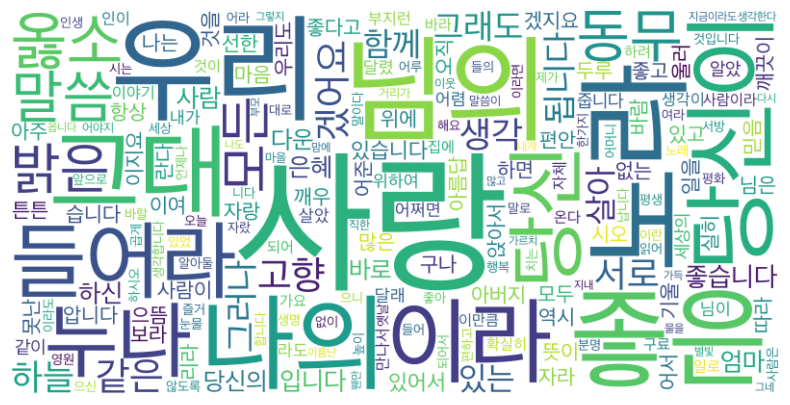

In [31]:
# ---- WordCloud
wc = WordCloud(
    font_path="/System/Library/Fonts/AppleSDGothicNeo.ttc",
    background_color="white",
    width=800,
    height=400
)

wc.generate_from_frequencies(token_scores)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()